In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import sys
sys.path.append("/home/z5297792/UNSW-MRes/MRes/modules") 
from utils import unit_det, fit_psi_params, psi_params, ellipse_aspect_ratio, axis_ratio_from_Q, espra

import re
def extract_number(s):
    match = re.search(r'\d+', s)
    return int(match.group()) if match else None


In [2]:
def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
    from scipy.optimize import least_squares
    def nan_return():
        nan2 = np.full((2, 2), np.nan)
        coeffs = pd.DataFrame(
            np.nan,
            index=['0', '1', '2', '3'],
            columns=['A', 'B', 'C', 'D']
        )
        return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan
        # return {
        #     'xc': np.nan,
        #     'yc': np.nan,
        #     'Omega': np.nan,
        #     'Q': nan2,
        #     'x0': np.nan,
        #     'y0': np.nan,
        #     'A': np.full(4, np.nan),
        #     'B': np.full(4, np.nan),
        #     'C': np.full(4, np.nan),
        #     'D': np.full(4, np.nan),
        #     'a0': np.nan, 'a1': np.nan,
        #     'b0': np.nan, 'b1': np.nan,
        #     'c0': np.nan, 'c1': np.nan,
        #     'd0': np.nan, 'd1': np.nan,
        #     'coeffs': coeffs,
        #     'success': False
        # }

    def clean(*arrs):
        arrs = [np.asarray(a, dtype=float).ravel() for a in arrs]
        m = np.logical_and.reduce([np.isfinite(a) for a in arrs])
        return [a[m] for a in arrs]

    def poly3(p, z):
        return p[0] + p[1]*z + p[2]*z**2 + p[3]*z**3

    def find_root(x, y, degree=3):
        if x.size < degree + 1:
            return np.nan

        try:
            coeffs = np.polyfit(x, y, degree)
            roots = np.roots(coeffs)
        except Exception:
            return np.nan

        real_roots = roots[np.isreal(roots)].real
        if real_roots.size == 0:
            return np.nan

        mid_x = np.median(x)
        return real_roots[np.argmin(np.abs(real_roots - mid_x))]

    x1, y1, u1, v1 = clean(x1, y1, u1, v1)
    x2, y2, u2, v2 = clean(x2, y2, u2, v2)

    if len(x1) < 4 or len(y2) < 4:
        return nan_return()

    pts1 = np.column_stack((x1, y1))
    pts2 = np.column_stack((x2, y2))

    common = np.array([p for p in pts1 if np.any(np.all(pts2 == p, axis=1))])

    if len(common) != 1:
        return nan_return()

    center_x, center_y = common[0]

    # Set origin at transect center
    x = x1 - center_x
    y = y2 - center_y

    # Initial guesses
    # Unconstrained cubic fits used only to estimate x0 and y0
    x0_guess = find_root(x, v1)
    y0_guess = find_root(y, u2)
    print(f'x0_guess: {x0_guess}, y0_guess: {y0_guess}')

    pA = np.polyfit(x, u1, 3)[::-1]
    pB = np.polyfit(x, v1, 3)[::-1]
    pC = np.polyfit(y, u2, 3)[::-1]
    pD = np.polyfit(y, v2, 3)[::-1]

    # Free parameters:
    # x0, y0,
    # A0,A1,A2,A3,
    # B1,B2,B3,   with B0 set so V1(x0)=0 exactly
    # C1,C2,C3,   with C0 set so U2(y0)=0 exactly
    # D0,D2,D3,   with D1 set so d1=-a1 exactly
    p0 = np.array([
        x0_guess, y0_guess,
        pA[0], pA[1], pA[2], pA[3],
        pB[1], pB[2], pB[3],
        pC[1], pC[2], pC[3],
        pD[0], pD[2], pD[3]
    ], dtype=float)

    def unpack(p):
        x0, y0 = p[0], p[1]

        A0, A1, A2, A3 = p[2:6]
        B1, B2, B3 = p[6:9]
        C1, C2, C3 = p[9:12]
        D0, D2, D3 = p[12:15]

        a1 = A1 + 2*A2*x0 + 3*A3*x0**2
        b1 = B1 + 2*B2*x0 + 3*B3*x0**2
        c1 = C1 + 2*C2*y0 + 3*C3*y0**2

        B0 = -x0 * b1 # V1(x0)=0 
        C0 = -y0 * c1 # U2(y0)=0 
        D1 = -a1 - 2*D2*y0 - 3*D3*y0**2 # d1=-a1

        A = np.array([A0, A1, A2, A3], dtype=float)
        B = np.array([B0, B1, B2, B3], dtype=float)
        C = np.array([C0, C1, C2, C3], dtype=float)
        D = np.array([D0, D1, D2, D3], dtype=float)

        return x0, y0, A, B, C, D

    def residuals(p):
        x0, y0, A, B, C, D = unpack(p)

        U1 = poly3(A, x)
        V1 = poly3(B, x)
        U2 = poly3(C, y)
        V2 = poly3(D, y)

        return np.r_[U1 - u1, V1 - v1, U2 - u2, V2 - v2]

    res = least_squares(residuals, p0, method='trf')

    if not res.success:
        return nan_return()

    x0, y0, A, B, C, D = unpack(res.x)
    print(f'x0: {x0}, y0: {y0}')

    A0, A1, A2, A3 = A
    B0, B1, B2, B3 = B
    C0, C1, C2, C3 = C
    D0, D1, D2, D3 = D

    # Tangent coefficients
    a1 = A1 + 2*A2*x0 + 3*A3*x0**2
    a0 = (A0 + A1*x0 + A2*x0**2 + A3*x0**3) - x0*a1

    b1 = B1 + 2*B2*x0 + 3*B3*x0**2
    b0 = -x0*b1

    c1 = C1 + 2*C2*y0 + 3*C3*y0**2
    c0 = -y0*c1

    d1 = D1 + 2*D2*y0 + 3*D3*y0**2
    d0 = (D0 + D1*y0 + D2*y0**2 + D3*y0**3) - y0*d1

    # Enforce d1 = -a1 numerically if tiny mismatch remains
    print(f'a1: {a1}, d1: {d1}')
    d1 = -a1

    radicand = -b1*c1 - a1**2
    if radicand <= 0 or not np.isfinite(radicand):
        return nan_return()

    Omega = np.sign(b1) * np.sqrt(radicand)
    if Omega == 0 or not np.isfinite(Omega):
        return nan_return()

    Q = (1 / Omega) * np.array([
        [b1,  -a1],
        [-a1, -c1]
    ], dtype=float)

    xc = (a0*a1 + c1*d0) / Omega**2
    yc = (a0*b1 - a1*d0) / Omega**2

    w = Omega * (Q[0,0] + Q[1,1])

    coeffs = pd.DataFrame(
        {
            'A': A,
            'B': B,
            'C': C,
            'D': D
        },
        index=['0', '1', '2', '3']
    )

    # return {
    #     'xc': xc,
    #     'yc': yc,
    #     'Omega': Omega,
    #     'Q': Q,
    #     'x0': x0,
    #     'y0': y0,
    #     'A': A,
    #     'B': B,
    #     'C': C,
    #     'D': D,
    #     'a0': a0, 'a1': a1,
    #     'b0': b0, 'b1': b1,
    #     'c0': c0, 'c1': c1,
    #     'd0': d0, 'd1': d1,
    #     'coeffs': coeffs,
    #     'success': True
    # }

    yu1 = a0 + a1*x
    yv1 = b0 + b1*x
    yu2 = c0 + c1*y
    yv2 = d0 + d1*y

    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(8, 6))

        xs = np.linspace(x.min(), x.max(), 400)
        ys = np.linspace(y.min(), y.max(), 400)

        U1s = poly3(A, xs)
        V1s = poly3(B, xs)
        U2s = poly3(C, ys)
        V2s = poly3(D, ys)

        axs[0, 0].scatter(x, u1, s=10)
        axs[0, 0].plot(xs, U1s)
        axs[0, 0].plot(x, yu1)
        axs[0, 0].axvline(x0, ls='--')
        axs[0, 0].set_title("U1(x)")

        axs[0, 1].scatter(x, v1, s=10)
        axs[0, 1].plot(xs, V1s)
        axs[0, 1].plot(x, yv1)
        axs[0, 1].axvline(x0, ls='--')
        axs[0, 1].axhline(0, ls='--')
        axs[0, 1].set_title("V1(x)")

        axs[1, 0].scatter(y, u2, s=10)
        axs[1, 0].plot(ys, U2s)
        axs[1, 0].plot(y, yu2)
        axs[1, 0].axvline(y0, ls='--')
        axs[1, 0].axhline(0, ls='--')
        axs[1, 0].set_title("U2(y)")

        axs[1, 1].scatter(y, v2, s=10)
        axs[1, 1].plot(ys, V2s)
        axs[1, 1].plot(y, yv2)
        axs[1, 1].axvline(y0, ls='--')
        axs[1, 1].set_title("V2(y)")

        plt.tight_layout()
        plt.show()

    return xc + center_x, yc + center_y, w, Q, Omega, yu1, yv1, yu2, yv2


# def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
# ################# Fixed x0, y0 ############################
#     from scipy.optimize import least_squares

#     def nan_return():
#         return np.nan, np.nan, np.nan, np.full((2, 2), np.nan), np.nan

#     def clean(*arrs):
#         arrs = [np.asarray(a, dtype=float).ravel() for a in arrs]
#         m = np.logical_and.reduce([np.isfinite(a) for a in arrs])
#         return [a[m] for a in arrs]

#     def poly3(p, z):
#         return p[0] + p[1]*z + p[2]*z**2 + p[3]*z**3

#     def find_root(x, y, degree=3):
#         if x.size < degree + 1:
#             return np.nan
#         try:
#             coeffs = np.polyfit(x, y, degree)
#             roots = np.roots(coeffs)
#         except Exception:
#             return np.nan

#         real_roots = roots[np.isreal(roots)].real
#         if real_roots.size == 0:
#             return np.nan

#         mid_x = np.median(x)
#         return real_roots[np.argmin(np.abs(real_roots - mid_x))]

#     x1, y1, u1, v1 = clean(x1, y1, u1, v1)
#     x2, y2, u2, v2 = clean(x2, y2, u2, v2)

#     if len(x1) < 4 or len(y2) < 4:
#         return nan_return()

#     pts1 = np.column_stack((x1, y1))
#     pts2 = np.column_stack((x2, y2))
#     common = np.array([p for p in pts1 if np.any(np.all(pts2 == p, axis=1))])

#     if len(common) != 1:
#         return nan_return()

#     center_x, center_y = common[0]

#     x = x1 - center_x
#     y = y2 - center_y

#     x0 = find_root(x, v1)
#     y0 = find_root(y, u2)

#     if not np.isfinite(x0) or not np.isfinite(y0):
#         return nan_return()

#     pA = np.polyfit(x, u1, 3)[::-1]
#     pB = np.polyfit(x, v1, 3)[::-1]
#     pC = np.polyfit(y, u2, 3)[::-1]
#     pD = np.polyfit(y, v2, 3)[::-1]

#     p0 = np.array([
#         pA[0], pA[1], pA[2], pA[3],
#         pB[1], pB[2], pB[3],
#         pC[1], pC[2], pC[3],
#         pD[0], pD[2], pD[3]
#     ], dtype=float)

#     def unpack(p):
#         A0, A1, A2, A3 = p[0:4]
#         B1, B2, B3 = p[4:7]
#         C1, C2, C3 = p[7:10]
#         D0, D2, D3 = p[10:13]

#         a1 = A1 + 2*A2*x0 + 3*A3*x0**2
#         b1 = B1 + 2*B2*x0 + 3*B3*x0**2
#         c1 = C1 + 2*C2*y0 + 3*C3*y0**2

#         B0 = -x0 * b1
#         C0 = -y0 * c1
#         D1 = -a1 - 2*D2*y0 - 3*D3*y0**2

#         A = np.array([A0, A1, A2, A3], dtype=float)
#         B = np.array([B0, B1, B2, B3], dtype=float)
#         C = np.array([C0, C1, C2, C3], dtype=float)
#         D = np.array([D0, D1, D2, D3], dtype=float)

#         return A, B, C, D

#     def residuals(p):
#         A, B, C, D = unpack(p)
#         return np.r_[
#             poly3(A, x) - u1,
#             poly3(B, x) - v1,
#             poly3(C, y) - u2,
#             poly3(D, y) - v2
#         ]

#     res = least_squares(residuals, p0, method='trf')

#     if not res.success:
#         return nan_return()

#     A, B, C, D = unpack(res.x)

#     A0, A1, A2, A3 = A
#     B0, B1, B2, B3 = B
#     C0, C1, C2, C3 = C
#     D0, D1, D2, D3 = D

#     a1 = A1 + 2*A2*x0 + 3*A3*x0**2
#     a0 = (A0 + A1*x0 + A2*x0**2 + A3*x0**3) - x0*a1

#     b1 = B1 + 2*B2*x0 + 3*B3*x0**2
#     b0 = -x0*b1

#     c1 = C1 + 2*C2*y0 + 3*C3*y0**2
#     c0 = -y0*c1

#     d1 = D1 + 2*D2*y0 + 3*D3*y0**2
#     d0 = (D0 + D1*y0 + D2*y0**2 + D3*y0**3) - y0*d1

#     d1 = -a1

#     radicand = -b1*c1 - a1**2
#     if radicand <= 0 or not np.isfinite(radicand):
#         return nan_return()

#     Omega = np.sign(b1) * np.sqrt(radicand)
#     if Omega == 0 or not np.isfinite(Omega):
#         return nan_return()

#     Q = (1 / Omega) * np.array([
#         [b1,  -a1],
#         [-a1, -c1]
#     ], dtype=float)

#     xc = (a0*a1 + c1*d0) / Omega**2
#     yc = (a0*b1 - a1*d0) / Omega**2

#     w = Omega * (Q[0, 0] + Q[1, 1])

#     yu1 = a0 + a1*x
#     yv1 = b0 + b1*x
#     yu2 = c0 + c1*y
#     yv2 = d0 + d1*y

#     if plot:
#         fig, axs = plt.subplots(2, 2, figsize=(8, 6))

#         xs = np.linspace(x.min(), x.max(), 400)
#         ys = np.linspace(y.min(), y.max(), 400)

#         U1s = poly3(A, xs)
#         V1s = poly3(B, xs)
#         U2s = poly3(C, ys)
#         V2s = poly3(D, ys)

#         axs[0, 0].scatter(x, u1, s=10)
#         axs[0, 0].plot(xs, U1s)
#         axs[0, 0].plot(x, yu1)
#         axs[0, 0].axvline(x0, ls='--')
#         axs[0, 0].set_title("U1(x)")

#         axs[0, 1].scatter(x, v1, s=10)
#         axs[0, 1].plot(xs, V1s)
#         axs[0, 1].plot(x, yv1)
#         axs[0, 1].axvline(x0, ls='--')
#         axs[0, 1].axhline(0, ls='--')
#         axs[0, 1].set_title("V1(x)")

#         axs[1, 0].scatter(y, u2, s=10)
#         axs[1, 0].plot(ys, U2s)
#         axs[1, 0].plot(y, yu2)
#         axs[1, 0].axvline(y0, ls='--')
#         axs[1, 0].axhline(0, ls='--')
#         axs[1, 0].set_title("U2(y)")

#         axs[1, 1].scatter(y, v2, s=10)
#         axs[1, 1].plot(ys, V2s)
#         axs[1, 1].plot(y, yv2)
#         axs[1, 1].axvline(y0, ls='--')
#         axs[1, 1].set_title("V2(y)")

#         plt.tight_layout()
#         plt.show()

#     return xc + center_x, yc + center_y, w, Q, Omega, yu1, yv1, yu2, yv2




In [3]:
# def doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=False):
#     from scipy.optimize import least_squares
#     def nan_return():
#         nan2 = np.full((2, 2), np.nan)
#         coeffs = pd.DataFrame(
#             np.nan,
#             index=['0', '1', '2', '3'],
#             columns=['A', 'B', 'C', 'D']
#         )
#         return np.nan, np.nan, np.nan, np.full((2,2), np.nan), np.nan
#         # return {
#         #     'xc': np.nan,
#         #     'yc': np.nan,
#         #     'Omega': np.nan,
#         #     'Q': nan2,
#         #     'x0': np.nan,
#         #     'y0': np.nan,
#         #     'A': np.full(4, np.nan),
#         #     'B': np.full(4, np.nan),
#         #     'C': np.full(4, np.nan),
#         #     'D': np.full(4, np.nan),
#         #     'a0': np.nan, 'a1': np.nan,
#         #     'b0': np.nan, 'b1': np.nan,
#         #     'c0': np.nan, 'c1': np.nan,
#         #     'd0': np.nan, 'd1': np.nan,
#         #     'coeffs': coeffs,
#         #     'success': False
#         # }

#     def clean(*arrs):
#         arrs = [np.asarray(a, dtype=float).ravel() for a in arrs]
#         m = np.logical_and.reduce([np.isfinite(a) for a in arrs])
#         return [a[m] for a in arrs]

#     def poly3(p, z):
#         return p[0] + p[1]*z + p[2]*z**2 + p[3]*z**3

#     def find_root(x, y, degree=3):
#         if x.size < degree + 1:
#             return np.nan

#         try:
#             coeffs = np.polyfit(x, y, degree)
#             roots = np.roots(coeffs)
#         except Exception:
#             return np.nan

#         real_roots = roots[np.isreal(roots)].real
#         if real_roots.size == 0:
#             return np.nan

#         mid_x = np.median(x)
#         return real_roots[np.argmin(np.abs(real_roots - mid_x))]

#     x1, y1, u1, v1 = clean(x1, y1, u1, v1)
#     x2, y2, u2, v2 = clean(x2, y2, u2, v2)

#     if len(x1) < 4 or len(x2) < 4:
#         return nan_return()

#     pts1 = np.column_stack((x1, y1))
#     pts2 = np.column_stack((x2, y2))
#     common = np.array([p for p in pts1 if np.any(np.all(pts2 == p, axis=1))])

#     if len(common) != 1:
#         return nan_return()

#     center_x, center_y = common[0]

#     x = x1 - center_x
#     y = y2 - center_y

#     # Unconstrained cubic fits used only to estimate x0 and y0
#     # pB_unc = np.polyfit(x, v1, 3)[::-1]
#     # pC_unc = np.polyfit(y, u2, 3)[::-1]

#     # x0_roots = real_roots_in_range(pB_unc, x.min(), x.max())
#     # y0_roots = real_roots_in_range(pC_unc, y.min(), y.max())

#     # x0 = choose_root(x0_roots, x)
#     # y0 = choose_root(y0_roots, y)

#     x0 = find_root(x, v1)
#     y0 = find_root(y, u2)

#     if not np.isfinite(x0) or not np.isfinite(y0):
#         return nan_return()

#     # Initial guesses for constrained fit
#     pA = np.polyfit(x, u1, 3)[::-1]
#     pB = np.polyfit(x, v1, 3)[::-1]
#     pC = np.polyfit(y, u2, 3)[::-1]
#     pD = np.polyfit(y, v2, 3)[::-1]

#     # Free parameters with x0, y0 fixed:
#     # A0,A1,A2,A3
#     # B1,B2,B3      and B0 = -x0*b1
#     # C1,C2,C3      and C0 = -y0*c1
#     # D0,D2,D3      and D1 from d1 = -a1
#     p0 = np.array([
#         pA[0], pA[1], pA[2], pA[3],
#         pB[1], pB[2], pB[3],
#         pC[1], pC[2], pC[3],
#         pD[0], pD[2], pD[3]
#     ], dtype=float)

#     def unpack(p):
#         A0, A1, A2, A3 = p[0:4]
#         B1, B2, B3 = p[4:7]
#         C1, C2, C3 = p[7:10]
#         D0, D2, D3 = p[10:13]

#         a1 = A1 + 2*A2*x0 + 3*A3*x0**2
#         b1 = B1 + 2*B2*x0 + 3*B3*x0**2
#         c1 = C1 + 2*C2*y0 + 3*C3*y0**2

#         B0 = -x0 * b1
#         C0 = -y0 * c1
#         D1 = -a1 - 2*D2*y0 - 3*D3*y0**2

#         A = np.array([A0, A1, A2, A3], dtype=float)
#         B = np.array([B0, B1, B2, B3], dtype=float)
#         C = np.array([C0, C1, C2, C3], dtype=float)
#         D = np.array([D0, D1, D2, D3], dtype=float)

#         return A, B, C, D

#     def residuals(p):
#         A, B, C, D = unpack(p)
#         U1 = poly3(A, x)
#         V1 = poly3(B, x)
#         U2 = poly3(C, y)
#         V2 = poly3(D, y)
#         return np.r_[U1 - u1, V1 - v1, U2 - u2, V2 - v2]

#     res = least_squares(residuals, p0, method='trf')

#     if not res.success:
#         return nan_return()

#     A, B, C, D = unpack(res.x)

#     A0, A1, A2, A3 = A
#     B0, B1, B2, B3 = B
#     C0, C1, C2, C3 = C
#     D0, D1, D2, D3 = D

#     a1 = A1 + 2*A2*x0 + 3*A3*x0**2
#     a0 = poly3(A, x0) - x0*a1

#     b1 = B1 + 2*B2*x0 + 3*B3*x0**2
#     b0 = -x0*b1

#     c1 = C1 + 2*C2*y0 + 3*C3*y0**2
#     c0 = -y0*c1

#     d1 = D1 + 2*D2*y0 + 3*D3*y0**2
#     d0 = poly3(D, y0) - y0*d1

#     # Enforce exact consistency
#     d1 = -a1

#     radicand = -b1*c1 - a1**2
#     if radicand <= 0 or not np.isfinite(radicand):
#         return nan_return()

#     Omega = np.sign(b1) * np.sqrt(radicand)
#     if Omega == 0 or not np.isfinite(Omega):
#         return nan_return()

#     Q = (1 / Omega) * np.array([
#         [b1,  -a1],
#         [-a1, -c1]
#     ], dtype=float)

#     xc = (a0*a1 + c1*d0) / Omega**2
#     yc = (a0*b1 - a1*d0) / Omega**2

#     coeffs = pd.DataFrame(
#         {'A': A, 'B': B, 'C': C, 'D': D},
#         index=['0', '1', '2', '3']
#     )

#     if plot:
#         fig, axs = plt.subplots(2, 2, figsize=(8, 6))

#         xs = np.linspace(x.min(), x.max(), 400)
#         ys = np.linspace(y.min(), y.max(), 400)

#         U1s = poly3(A, xs)
#         V1s = poly3(B, xs)
#         U2s = poly3(C, ys)
#         V2s = poly3(D, ys)

#         axs[0, 0].scatter(x, u1, s=10)
#         axs[0, 0].plot(xs, U1s)
#         axs[0, 0].axvline(x0, ls='--')
#         axs[0, 0].set_title("U1(x)")

#         axs[0, 1].scatter(x, v1, s=10)
#         axs[0, 1].plot(xs, V1s)
#         axs[0, 1].axvline(x0, ls='--')
#         axs[0, 1].axhline(0, ls='--')
#         axs[0, 1].set_title("V1(x)")

#         axs[1, 0].scatter(y, u2, s=10)
#         axs[1, 0].plot(ys, U2s)
#         axs[1, 0].axvline(y0, ls='--')
#         axs[1, 0].axhline(0, ls='--')
#         axs[1, 0].set_title("U2(y)")

#         axs[1, 1].scatter(y, v2, s=10)
#         axs[1, 1].plot(ys, V2s)
#         axs[1, 1].axvline(y0, ls='--')
#         axs[1, 1].set_title("V2(y)")

#         plt.tight_layout()
#         plt.show()

#     # return {
#     #     'xc': xc + center_x,
#     #     'yc': yc + center_y,
#     #     'Omega': Omega,
#     #     'Q': Q,
#     #     'x0': x0,
#     #     'y0': y0,
#     #     'A': A,
#     #     'B': B,
#     #     'C': C,
#     #     'D': D,
#     #     'a0': a0, 'a1': a1,
#     #     'b0': b0, 'b1': b1,
#     #     'c0': c0, 'c1': c1,
#     #     'd0': d0, 'd1': d1,
#     #     'coeffs': coeffs,
#     #     'success': True
#     # }

#     return xc + center_x, yc + center_y, w, Q, Omega


In [4]:
def out_core_param_fit(
    rho2, Qr, vt,
    Omega0=None, Rc0=None,
    plot=False, ax=None,
    maxfev=10000, Rc_max=1e5,
    r2_flag=False,
    rho_plot_max=None, n_curve=400,
    ci_flag=False,
    pred_flag=False,
    clr='b'
):

    from scipy.optimize import curve_fit

    rho2 = np.asarray(rho2, float)
    Qr   = np.asarray(Qr, float)
    vt   = np.asarray(vt, float)

    m = np.isfinite(rho2) & np.isfinite(Qr) & np.isfinite(vt) & (rho2 >= 0) & (Qr != 0)
    if not np.any(m):
        return (np.nan, np.nan, np.nan, np.nan) if r2_flag else (np.nan, np.nan, np.nan)

    rho2 = rho2[m]
    Qr   = Qr[m]
    vt   = vt[m]
    
    rho = np.sqrt(rho2)
    vt = vt * (rho / Qr)

    def vt_model(r2, Omega, Rc):
        return Omega * np.sqrt(r2) * np.exp(-r2 / (Rc**2))

    i = np.nanargmax(np.abs(vt))
    rho_max = rho[i]

    if Rc0 is None:
        Rc0 = max(rho_max * np.sqrt(2), 1e-6)

    if Omega0 is None:
        denom = rho * np.exp(-rho2 / (Rc0**2))
        ok = np.abs(denom) > 0
        Omega0 = np.nanmedian(vt[ok] / denom[ok]) if np.any(ok) else 0

    if not np.isfinite(Omega0):
        Omega0 = 0

    pcov = None
    try:
        popt, pcov = curve_fit(
            vt_model, rho2, vt,
            p0=[Omega0, Rc0],
            bounds=([-np.inf, 1e-8], [np.inf, np.inf]),
            maxfev=maxfev
        )
        Omega_opt, Rc_opt = popt
    except:
        Omega_opt, Rc_opt = Omega0, Rc0

    if (not np.isfinite(Rc_opt)) or (Rc_opt > Rc_max):
        Omega_opt, Rc_opt = Omega0, Rc0
        pcov = None

    psi0_opt = -0.5 * Omega_opt * Rc_opt**2

    vt_fit = vt_model(rho2, Omega_opt, Rc_opt)

    ss_res = np.sum((vt - vt_fit)**2)
    ss_tot = np.sum((vt - vt.mean())**2)
    R2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

    dof = max(len(vt) - 2, 1)
    sigma2 = ss_res / dof

    if plot:

        if ax is None:
            fig, ax = plt.subplots()

        if rho_plot_max is None:
            rho_plot_max = np.nanmax(rho)

        # r_grid = np.linspace(0, rho_plot_max, n_curve)
        r_grid = np.linspace(0.0, 110, n_curve)
        r2_grid = r_grid**2

        vt_grid = vt_model(r2_grid, Omega_opt, Rc_opt)

        ax.scatter(rho, np.abs(vt), s=40, marker='x', zorder=2, color=clr)

        mask = r_grid<=rho_plot_max
        ax.plot(r_grid[mask], np.abs(vt_grid[mask]), lw=2, color='c', zorder=1)
        ax.plot(r_grid[~mask], np.abs(vt_grid[~mask]), lw=2, color='c', zorder=1, alpha=.3)
        # ax.plot(r_grid, np.abs(vt_grid), lw=2, color=clr, label='')
        
        ax.axvline(Rc_opt / np.sqrt(2), ls='--', color=clr, label='', lw=2)

        if pcov is not None:

            exp_term = np.exp(-r2_grid / (Rc_opt**2))

            dOmega = np.sqrt(r2_grid) * exp_term
            dRc = 2 * Omega_opt * (r2_grid**1.5) * exp_term / (Rc_opt**3)

            J = np.vstack([dOmega, dRc]).T
            var_model = np.einsum("ij,jk,ik->i", J, pcov, J)

            if ci_flag:
                se_model = np.sqrt(np.maximum(var_model, 0))
                lo = vt_grid - 1.96 * se_model
                hi = vt_grid + 1.96 * se_model

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='orange', alpha=.2, label='95% CI'
                )

            if pred_flag:
                se_pred = np.sqrt(np.maximum(var_model + sigma2, 0))
                lo = vt_grid - 1.96 * se_pred
                hi = vt_grid + 1.96 * se_pred

                ax.fill_between(
                    r_grid, np.abs(lo), np.abs(hi),
                    color='b', alpha=.15, label=''
                )

        ax.set_xlabel(r'$\rho$')
        ax.set_ylabel(r'$|v_t^\star|$')

        ax.set_title(
            f"Omega={Omega_opt:.3g}, Rc={Rc_opt:.3g}, psi0={psi0_opt:.3g}, R²={R2:.2f}"
        )

        # ax.legend()

    return (Rc_opt, psi0_opt, Omega_opt, R2) if r2_flag else (Rc_opt, psi0_opt, Omega_opt)
    

In [5]:
width=500
x = np.linspace(-width // 2, width // 2, 501)
y = np.linspace(-width // 2, width // 2, 501)
X, Y = np.meshgrid(x, y, indexing='ij')

xc, yc = 0.0, 0.0
Q11, Q12, Q22 = 1, .4, 1
psi0 = 250.0 
Rc = 85.0 
A = - psi0 / Rc**2

# rescale Q to have unit determinant
Q, _ = unit_det(Q=np.array([[Q11, Q12], [Q12, Q22]]))
q11, q12, q22 = Q[0,0], Q[0,1], Q[1,1]

w = 2*A*(q11+q22)*1e-3
Omega = 2*A*1e-3

dx, dy = X - xc, Y - yc
rho2 = q11*dx**2 + 2*q12*dx*dy + q22*dy**2
Qr2 = (q11*dx + q12*dy)**2 + (q12*dx + q22*dy)**2 # ||Qr||
psi = psi0 * np.exp( - rho2 / Rc**2 )
u =   psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q12*dx + 2*q22*dy ) / Rc**2
v = - psi0 * np.exp( - rho2 / Rc**2 ) * ( 2*q11*dx + 2*q12*dy ) / Rc**2


x0_guess: -14.039761376397534, y0_guess: -14.039761376397536
x0: -13.643003088139018, y0: -13.643003089105987
a1: 0.02939029037849472, d1: -0.02939029037849472


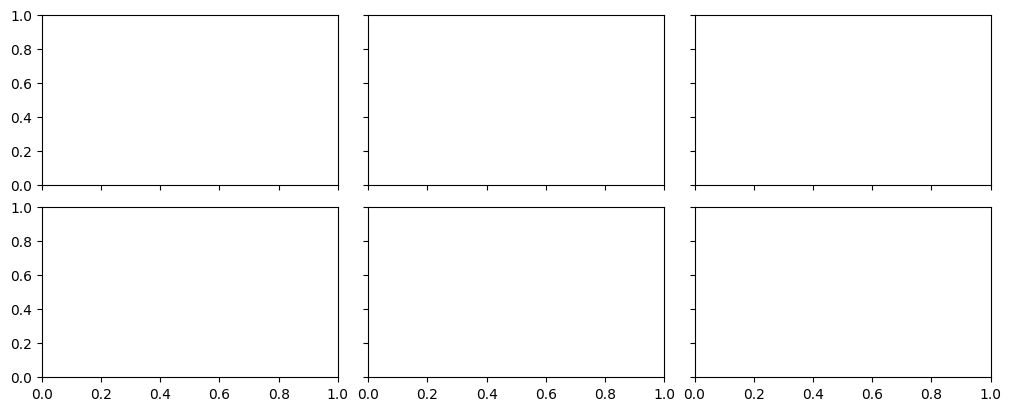

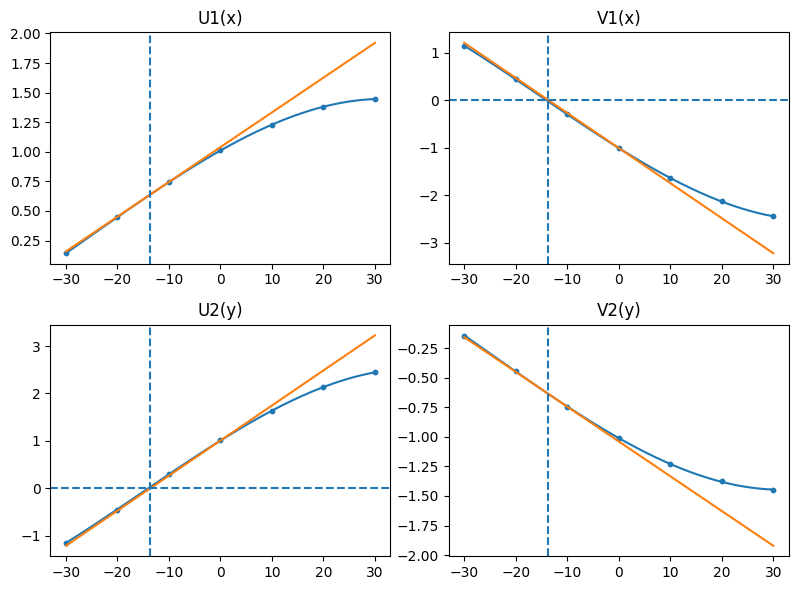

x0_guess: 15.050539513441047, y0_guess: -15.050539513441036
x0: 14.555190817630336, y0: -14.555190817198302
a1: 0.028067322528125337, d1: -0.028067322528125334


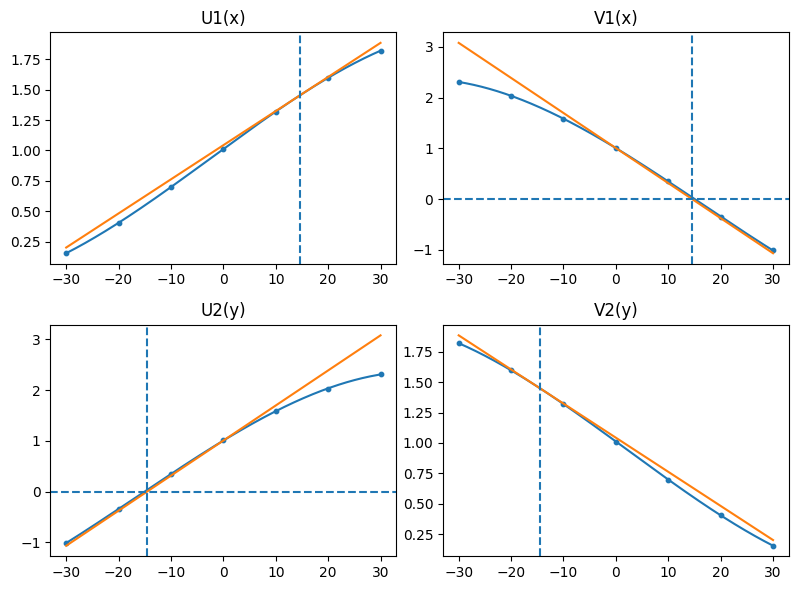

x0_guess: 40.59536108405791, y0_guess: 40.59536108405791
x0: 31.363124082137034, y0: 31.363124085358344
a1: 0.022425868612150495, d1: -0.022425868612150495


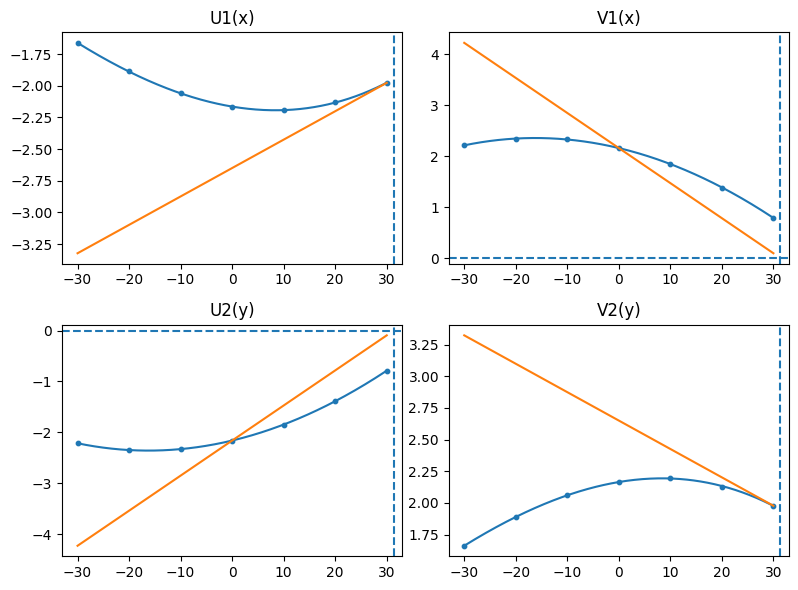

x0_guess: -14.017396082157815, y0_guess: -14.017396082157813
x0: -13.588729475140099, y0: -13.588729475098113
a1: 0.029705242576336263, d1: -0.02970524257633626


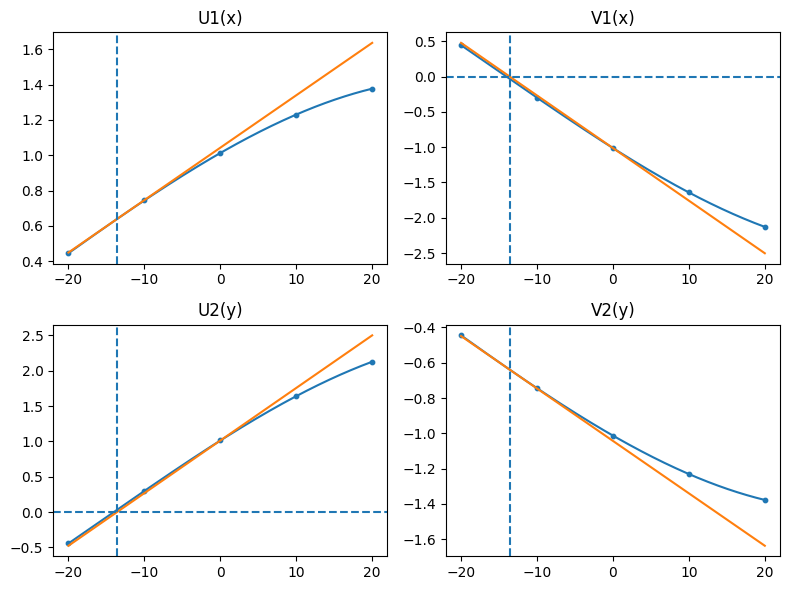

x0_guess: -14.039761376397534, y0_guess: -14.039761376397536
x0: -13.643003088139018, y0: -13.643003089105987
a1: 0.02939029037849472, d1: -0.02939029037849472


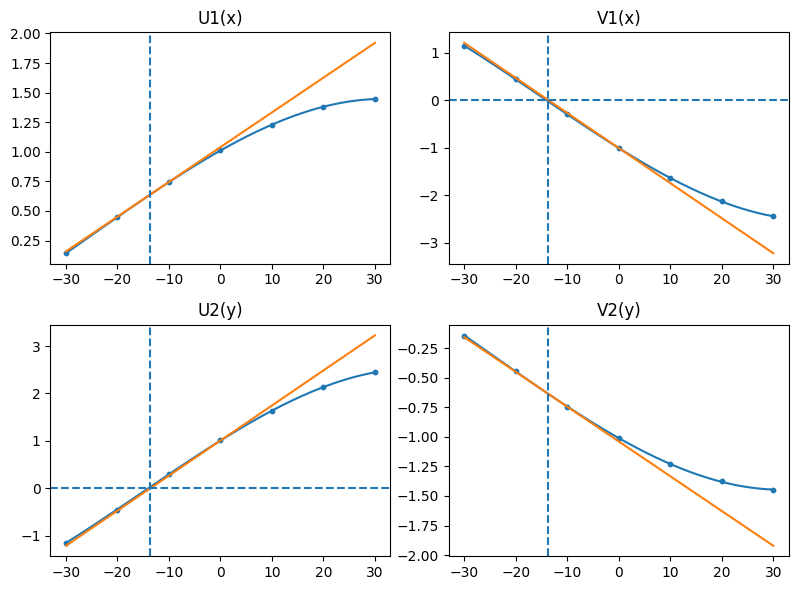

x0_guess: -14.037372147847574, y0_guess: -14.037372147847577
x0: -13.679958021732102, y0: -13.679958020492933
a1: 0.028935280667274882, d1: -0.028935280667274882


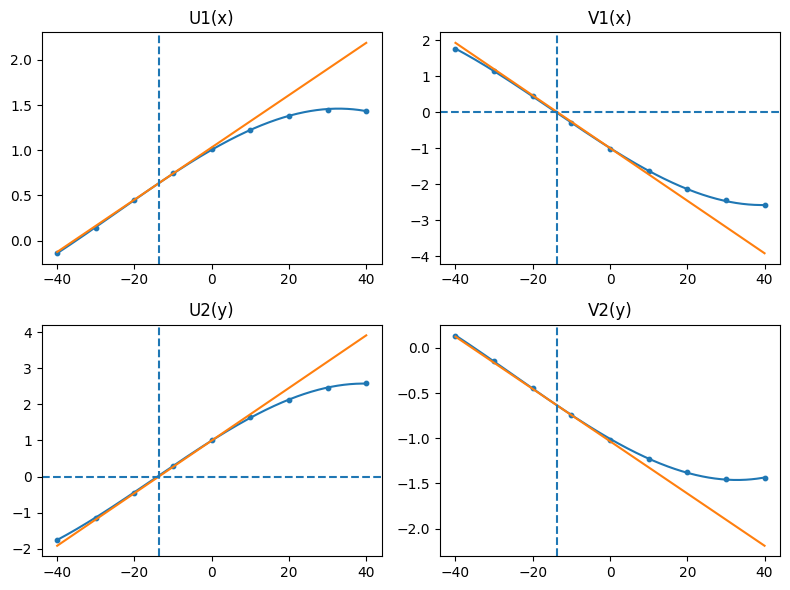

,xc,yc,w,q11,q12,q22,Rc,psi0,Omega
Control,0.000000,0.000000,-0.000151,1.091089,0.436436,1.091089,85.000000,250.000000,-0.000069
P1,-0.061756,-0.061756,-0.000148,1.089931,0.433532,1.089931,85.295308,251.422395,-0.000069
P2,0.409749,-0.409749,-0.000138,1.094269,0.444324,1.094269,86.154608,254.362883,-0.000069
P3,-0.975451,-0.975451,-0.000138,1.057663,0.344459,1.057663,79.542198,244.940945,-0.000077
L1,-0.008558,-0.008558,-0.000149,1.090455,0.434847,1.090455,85.279697,251.586603,-0.000069
L2,-0.061756,-0.061756,-0.000148,1.089931,0.433532,1.089931,85.295308,251.422395,-0.000069
L3,-0.127344,-0.127344,-0.000146,1.089255,0.431830,1.089255,85.177156,250.978021,-0.000069


In [6]:
df_res = pd.DataFrame({'xc': [xc], 'yc': [yc], 'w': [w], 'q11': [q11], 'q12': [q12], 'q22': [q22],
                        'Rc': [Rc], 'psi0': [psi0], 'Omega': [Omega]})

nic, njc = 52, 52
r = 6

df_tests = pd.DataFrame({
    'nic': [nic, 45, 44, nic, nic, nic],
    'njc': [njc, 55, 44, njc, njc, njc],
    'r': [r, r, r, r-2, r, r+2]
}, index=['P1', 'P2', 'P3', 'L1', 'L2', 'L3'])

df_tests = df_tests*5

fig, axs = plt.subplots(2, 3, constrained_layout=True, figsize=(10, 4), sharey=True, sharex=True)
axs = axs.flatten()

dic_tests = {}
skip = 10
clrs = ['g', 'r', 'b']*2
for t, test in enumerate(df_tests.index):
    data = df_tests.loc[test]

    x1 = x[data.nic-data.r:data.nic+data.r+1:skip]
    y1 = np.array([y[data.njc]] * len(x1))

    u1 = u[data.nic-data.r:data.nic+data.r+1:skip, data.njc]
    v1 = v[data.nic-data.r:data.nic+data.r+1:skip, data.njc]

    y2 = y[data.njc-data.r:data.njc+data.r+1:skip]
    x2 = np.array([x[data.nic]] * len(y2))

    u2 = u[data.nic, data.njc-data.r:data.njc+data.r+1:skip]
    v2 = v[data.nic, data.njc-data.r:data.njc+data.r+1:skip]

    points1 = set(zip(x1, y1)); points2 = set(zip(x2, y2))
    common_points = points1 & points2
    # Remove duplicates from (x1, y1, u1, v1)
    mask = ~np.array([(x, y) in common_points for x, y in zip(x1, y1)])
    x1f = x1[mask]; y1f = y1[mask]; u1f = u1[mask]; v1f = v1[mask]
    # Concatenate with unaltered second set
    xi = np.concatenate([x1f, x2]); yi = np.concatenate([y1f, y2])
    ui = np.concatenate([u1f, u2]); vi = np.concatenate([v1f, v2])

    xc_dop, yc_dop, w_dop, Q_dop, Omega_dop, yu1, yv1, yu2, yv2 = doppio(x1, y1, u1, v1, x2, y2, u2, v2, plot=True)

    # xc_dop, yc_dop, w_dop, Q_dop, Omega_dop, df = doppio(x1, y1, u1, v1, x2, y2, u2, v2)
    # print(df)
                                                                    
    # print(param_finder(x1, y1, u1, v1, x2, y2, u2, v2, plot=True))

    df = psi_params(xc_dop, yc_dop, Q_dop, xi, yi, ui, vi)
    Rc_dop, psi0_dop, Omega_dop = out_core_param_fit(df.rho2, df.Qr, df.vt, Omega0=Omega_dop, 
                                     Rc_max=1e6, clr=clrs[t], ax=axs[t], plot=False)
    
    w_dop *= 1e-3
    Omega_dop *= 1e-3
    
    # dic_tests[test] = {'x1': x1, 'y1': y1, 'u1': u1, 'v1': v1,
    #                    'x2': x2, 'y2': y2, 'u2': u2, 'v2': v2,
    #                    'name': test}#, 'U1': U1, 'V1': V1, 'U2': U2, 'V2': V2}
    dic_tests[test] = {'x1': x1, 'y1': y1, 'u1': u1, 'v1': v1,
                       'x2': x2, 'y2': y2, 'u2': u2, 'v2': v2,
                       'name': test, 'yu1': yu1, 'yv1': yv1,
                       'yu2': yu2, 'yv2': yv2}

    
    df_res.loc[len(df_res)] = {'xc': xc_dop, 'yc': yc_dop, 'w': w_dop,
                               'q11': Q_dop[0,0], 'q12': Q_dop[0,1], 'q22': Q_dop[1,1],
                               'Rc': Rc_dop, 'psi0': psi0_dop, 'Omega': Omega_dop}

for a, ax in enumerate(axs):
    # if a%2==0:
    ax.set_title('E'+df_tests.index[a])
    ax.set_xlabel(r'$\rho$ (km)')
    if a in [0, 3]:
        ax.set_ylabel(r'$|v_t^\star|$ (ms$^{-1}$)')
    else:
        ax.set_ylabel('')
    ax.axvline(Rc/np.sqrt(2), color='k', zorder=-1, alpha=.5)

df_res.index = ['Control'] + list(df_tests.index)
df_res


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


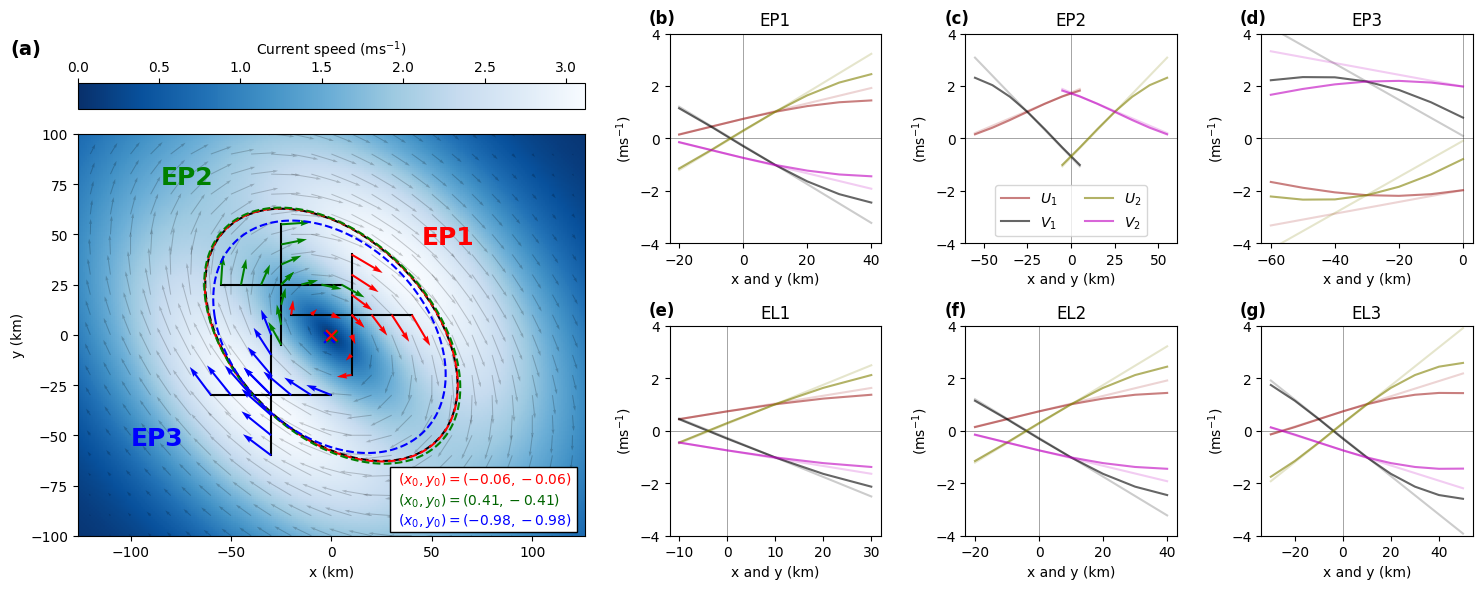

In [7]:
import matplotlib.gridspec as gridspec
from matplotlib.patches import Rectangle

fig = plt.figure(figsize=(15, 6))
gs = gridspec.GridSpec(2, 5, figure=fig)

# Main panel takes first two columns
ax_main = fig.add_subplot(gs[:, :2])

cmap = 'Blues_r'
spacing, scale, width = 10, 40, 0.002

pc = ax_main.pcolor(x, y, np.hypot(u, v).T, cmap=cmap)
plt.colorbar(
    pc, ax=ax_main, orientation='horizontal',
    location='top', label='Current speed (ms$^{-1}$)'
)

ax_main.quiver(
    x[::spacing], y[::spacing],
    u[::spacing, ::spacing].T, v[::spacing, ::spacing].T,
    alpha=0.2, scale=scale, width=width
)

ax_main.contour(X, Y, rho2, levels=[Rc**2/2], colors='k', linestyles='--')

colours = ['r', 'g', 'b']
color = ['r', 'g', 'b']

i = 0
for dic in dic_tests.values():
    if 'P' in dic['name']:
        x1, y1, u1, v1, x2, y2, u2, v2 = (dic[k] for k in ['x1', 'y1', 'u1', 'v1', 'x2', 'y2', 'u2', 'v2'])
        data = df_res.loc[dic['name']]

        ax_main.plot(x1, y1, 'k', zorder=2)
        ax_main.plot(x2, y2, 'k', zorder=2)

        ax_main.quiver(x1, y1, u1, v1, scale=scale, width=width*2, color=colours[i], zorder=3)
        ax_main.quiver(x2, y2, u2, v2, scale=scale, width=width*2, color=colours[i], zorder=3)
        ax_main.scatter(
            data.xc, data.yc, marker='x', s=60, color=colours[i],
            zorder=20-extract_number(dic['name'])
        )

        dx_ell, dy_ell = X - data.xc, Y - data.yc
        rho2_ell = data.q11*dx_ell**2 + 2*data.q12*dx_ell*dy_ell + data.q22*dy_ell**2
        ax_main.contour(
            X, Y, rho2_ell, levels=[data.Rc**2/2],
            colors=colours[i], linestyles='--', zorder=3
        )

        ax_main.text(
            33, -74 - 10*i,
            fr'$(x_0,y_0)=({data.xc:.2f},{data.yc:.2f})$',
            color='darkgreen' if '2' in dic['name'] else colours[i],
            zorder=11
        )
        i += 1

x_pos, y_pos = 0.80, 0.09
box_width = 0.37
box_height = 0.16
rect = Rectangle(
    (x_pos - box_width / 2, y_pos - box_height / 2),
    box_width, box_height,
    transform=ax_main.transAxes,
    facecolor='white', edgecolor='black', zorder=10
)
ax_main.add_patch(rect)

ax_main.text(-160, 140, '(a)', fontsize=14, fontweight='bold')
ax_main.axis('equal')
ax_main.set_xlim(-100, 100)
ax_main.set_ylim(-100, 100)
ax_main.set_xlabel('x (km)')
ax_main.set_ylabel('y (km)')

# # The flip point lines
# xT = np.linspace(-75, 75, 100)
# y0 = -q12/q22 * xT
# ax_main.plot(xT, y0, color='orange', zorder=1)
# yT = np.linspace(-75, 75, 100)
# x0 = -q12/q11 * yT
# ax_main.plot(x0, yT, color='orange', zorder=1)

axs = []
tags = ['(b)','(c)', '(d)', '(e)', '(f)','(g)']

for d, dic in enumerate(dic_tests.values()):
    x1, y1, u1, v1, x2, y2, u2, v2 = (dic[k] for k in ['x1', 'y1', 'u1', 'v1', 'x2', 'y2', 'u2', 'v2'])
    yu1, yv1, yu2, yv2 = (dic[k] for k in ['yu1', 'yv1', 'yu2', 'yv2'])
    data = df_res.loc[dic['name']]

    # Put small panels in cols 2, 3, 4
    ax2 = fig.add_subplot(gs[d // 3, 2 + (d % 3)])

    ax2.plot(x1, u1, color='brown', label=r'$U_1$', alpha=.6)
    ax2.plot(x1, yu1, color='brown', alpha=.2)#, marker='*')
    ax2.plot(x1, v1, 'k', label=r'$V_1$', alpha=.6)
    ax2.plot(x1, yv1, 'k', alpha=.2)#, marker='*')
    ax2.plot(y2, u2, color='olive', label=r'$U_2$', alpha=.6)
    ax2.plot(y2, yu2, color='olive', alpha=.2)#, marker='*')
    ax2.plot(y2, v2, 'm', label=r'$V_2$', alpha=.6)
    ax2.plot(y2, yv2, 'm', alpha=.2)#, marker='*')

    ax2.axhline(y=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
    ax2.axvline(x=0, color='k', zorder=-1, linewidth=.5, alpha=.5)
    ax2.set_ylabel('(ms$^{-1}$)')
    ax2.set_xlabel('x and y (km)')
    ax2.set_title('E' + dic['name'])

    if dic['name']=='P2':
        ax2.legend(loc='lower center', ncol=2)

    axs.append(ax2)

    ax2.text(-0.1, 1.05, tags[d], fontsize=12, fontweight='bold', transform=ax2.transAxes)

ymin = -4 #min(ax.get_ylim()[0] for ax in axs)
ymax = 4 #max(ax.get_ylim()[1] for ax in axs)
for ax in axs:
    ax.set_ylim(ymin, ymax)

ax_main.text(45, 45, 'EP1', color=color[0], zorder=3, fontsize=18, fontweight='bold')
ax_main.text(-85, 75, 'EP2', color=color[1], zorder=3, fontsize=18, fontweight='bold')
ax_main.text(-100, -55, 'EP3', color=color[2], zorder=3, fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


In [8]:
df_paper = df_res.copy()
df_paper['alpha'] = [axis_ratio_from_Q(np.array([[q11, q12], [q12, q22]])) for (q11, q12, q22) in zip(df_paper.q11, df_paper.q12, df_paper.q22)]
df_paper = df_paper.drop(columns=['q11', 'q12', 'q22'])
df_paper


,xc,yc,w,Rc,psi0,Omega,alpha
Control,0.000000,0.000000,-0.000151,85.000000,250.000000,-0.000069,1.527525
P1,-0.061756,-0.061756,-0.000148,85.295308,251.422395,-0.000069,1.523463
P2,0.409749,-0.409749,-0.000138,86.154608,254.362883,-0.000069,1.538592
P3,-0.975451,-0.975451,-0.000138,79.542198,244.940945,-0.000077,1.402122
L1,-0.008558,-0.008558,-0.000149,85.279697,251.586603,-0.000069,1.525301
L2,-0.061756,-0.061756,-0.000148,85.295308,251.422395,-0.000069,1.523463
L3,-0.127344,-0.127344,-0.000146,85.177156,250.978021,-0.000069,1.521085


In [9]:
df_err = (df_paper - df_paper.iloc[0]).abs().iloc[1:]
df_err.index = ['EP1 Err', 'EP2 Err', 'EP3 Err',
                'EL1 Err', 'EL2 Err', 'EL3 Err']
df_err


,xc,yc,w,Rc,psi0,Omega,alpha
EP1 Err,0.061756,0.061756,0.000003,0.295308,1.422395,8.734519e-08,0.004063
EP2 Err,0.409749,0.409749,0.000013,1.154608,4.362883,6.668969e-07,0.011067
EP3 Err,0.975451,0.975451,0.000013,5.457802,5.059055,8.223520e-06,0.125403
EL1 Err,0.008558,0.008558,0.000002,0.279697,1.586603,1.687995e-08,0.002224
EL2 Err,0.061756,0.061756,0.000003,0.295308,1.422395,8.734519e-08,0.004063
EL3 Err,0.127344,0.127344,0.000005,0.177156,0.978021,1.796250e-08,0.006440


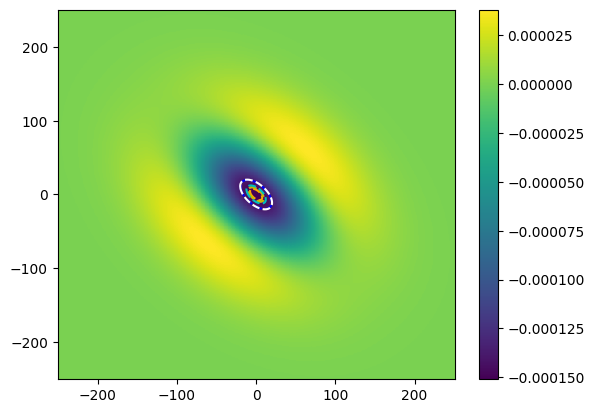

In [10]:
dx = (X[1,0] - X[0,0])*1e3
dy = (Y[0,1] - Y[0,0])*1e3

dv_dx = np.gradient(v, dx, axis=0)
du_dy = np.gradient(u, dy, axis=1)

zeta = dv_dx - du_dy
plt.pcolor(X, Y, zeta)
plt.colorbar()
clrs =['r', 'm', 'b', 'w', 'orange', 'y', 'c']
for i, clr in enumerate(clrs):
    plt.contour(X, Y, zeta, levels=[df_res.iloc[i].w], colors=clr) 
    

### Pres Plots

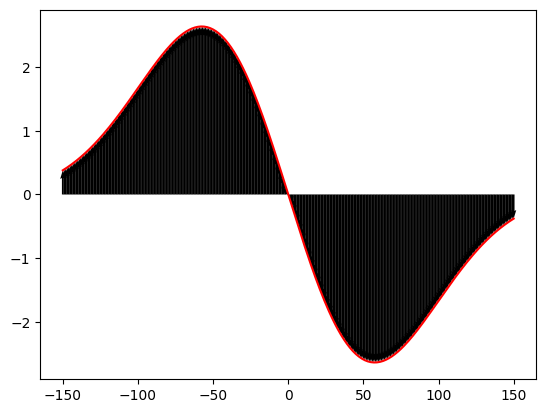

In [11]:
data = pd.DataFrame({'nic': [50], 'njc': [50], 'r': [30]}).iloc[0]*5

x1 = x[data.nic-data.r:data.nic+data.r+1]
y1 = np.array([y[data.njc]] * len(x1))

u1 = u[data.nic-data.r:data.nic+data.r+1, data.njc]
v1 = v[data.nic-data.r:data.nic+data.r+1, data.njc]


plt.quiver(x1, [0]*len(x1), [0]*len(v1), v1, scale_units='xy', scale=1)
plt.plot(x1, v1, color='r') 



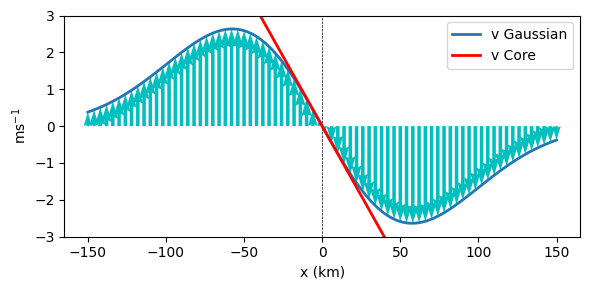

In [12]:
plt.figure(figsize=(6,3))
plt.axvline(x=0, color='k', linewidth=.5, linestyle='--')
plt.plot(x1, v1, linewidth=2, label='v Gaussian')
spac = 4
plt.quiver(x1[::spac], [0]*len(x1[::spac]), [0]*len(v1[::spac]), v1[::spac], scale_units='xy', scale=1, color='c')

vcore = 2*A*q11*(x1-xc) + 2*A*q12*(y1-yc)
plt.plot(x1, vcore, 'r-', linewidth=2, label='v Core')

plt.legend()
plt.xlabel(r'x (km)')
plt.ylabel(r'ms$^{-1}$')
plt.ylim(-3, 3)
plt.tight_layout()


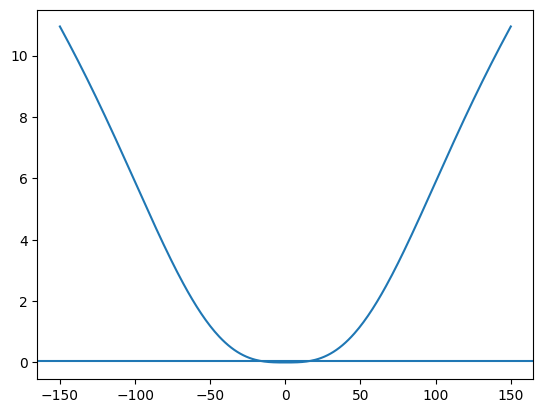

In [13]:
plt.plot(x1, np.abs(vcore-v1))
plt.axhline(y=.05)


#### LATTE

In [14]:
df_tests

,nic,njc,r
P1,260,260,30
P2,225,275,30
P3,220,220,30
L1,260,260,20
L2,260,260,30
L3,260,260,40


In [15]:
df_latte_res = df_res.copy()
df_latte_res['Method'] = 'doppio'

for t, test in enumerate(df_tests.index):
    data = df_tests.loc[test]

    x1 = x[data.nic-data.r:data.nic+data.r+1:skip]
    y1 = np.array([y[data.njc]] * len(x1))

    u1 = u[data.nic-data.r:data.nic+data.r+1:skip, data.njc]
    v1 = v[data.nic-data.r:data.nic+data.r+1:skip, data.njc]

    y2 = y[data.njc-data.r:data.njc+data.r+1:skip]
    x2 = np.array([x[data.nic]] * len(y2))

    u2 = u[data.nic, data.njc-data.r:data.njc+data.r+1:skip]
    v2 = v[data.nic, data.njc-data.r:data.njc+data.r+1:skip]

    points1 = set(zip(x1, y1)); points2 = set(zip(x2, y2))
    common_points = points1 & points2
    # Remove duplicates from (x1, y1, u1, v1)
    mask = ~np.array([(x, y) in common_points for x, y in zip(x1, y1)])
    x1f = x1[mask]; y1f = y1[mask]; u1f = u1[mask]; v1f = v1[mask]
    # Concatenate with unaltered second set
    xi = np.concatenate([x1f, x2]); yi = np.concatenate([y1f, y2])
    ui = np.concatenate([u1f, u2]); vi = np.concatenate([v1f, v2])

    xc_lat, yc_lat, w_lat, Q_lat, Rc_lat, psi0_lat, A_lat = espra(xi, yi, ui, vi, plot_flag=False)
    w_lat *= 1e-3
    A_lat *= 1e-3
    
    df = psi_params(xc_dop, yc_dop, Q_dop, xi, yi, ui, vi)
    
    df_latte_res.loc[len(df_latte_res)] = {'xc': xc_lat, 'yc': yc_lat, 'w': w_lat,
                               'q11': Q_lat[0,0], 'q12': Q_lat[0,1], 'q22': Q_lat[1,1],
                               'Rc': Rc_lat, 'psi0': psi0_lat, 'Omega': 2*A_lat, 'Method': 'latte'}
df_latte_res.index = list(df_latte_res.index[:7]) + ['P1', 'P2', 'P3', 'L1', 'L2', 'L3']

df_latte_res['alpha'] = [axis_ratio_from_Q(np.array([[q11, q12], [q12, q22]])) for (q11, q12, q22) in zip(df_latte_res.q11, df_latte_res.q12, df_latte_res.q22)]
df_latte_res = df_latte_res.drop(columns=['q11', 'q12', 'q22'])


df_latte_res


,xc,yc,w,Rc,psi0,Omega,Method,alpha
Control,0.000000,0.000000,-0.000151,85.000000,250.000000,-0.000069,doppio,1.527525
P1,-0.061756,-0.061756,-0.000148,85.295308,251.422395,-0.000069,doppio,1.523463
P2,0.409749,-0.409749,-0.000138,86.154608,254.362883,-0.000069,doppio,1.538592
P3,-0.975451,-0.975451,-0.000138,79.542198,244.940945,-0.000077,doppio,1.402122
L1,-0.008558,-0.008558,-0.000149,85.279697,251.586603,-0.000069,doppio,1.525301
L2,-0.061756,-0.061756,-0.000148,85.295308,251.422395,-0.000069,doppio,1.523463
L3,-0.127344,-0.127344,-0.000146,85.177156,250.978021,-0.000069,doppio,1.521085
P1,-0.359387,-0.359387,-0.000148,89.232516,275.209957,-0.000069,latte,1.461784
P2,7.282728,-7.282728,-0.000137,106.548671,336.915018,-0.000059,latte,1.735671
P3,75.178450,75.178451,-0.000055,370.115185,1819.124830,-0.000027,latte,1.269722


In [16]:
df = df_latte_res.copy()

ctrl = df.loc['Control']

def compute_errors(df, ctrl):
    out = df.copy()
    out['err_xy'] = np.hypot(df['xc'] - ctrl['xc'], df['yc'] - ctrl['yc'])
    out['err_w'] = np.abs(df['w'] - ctrl['w'])
    out['err_Omega'] = np.abs(df['Omega'] - ctrl['Omega'])
    out['err_alpha'] = np.abs(df['alpha'] - ctrl['alpha'])
    out['err_Rc'] = np.abs(df['Rc'] - ctrl['Rc'])
    return out

df_err = compute_errors(df.iloc[1:], ctrl).copy()
df_err['case'] = df_err.index

dop = df_err[df_err['Method'] == 'doppio'].set_index('case')
lat = df_err[df_err['Method'] == 'latte'].set_index('case')

eps = 1e-12

comp = pd.DataFrame({
    r'$(x_0,y_0)$ $\Delta e$': lat['err_xy'] - dop['err_xy'],
    r'$w$ $\Delta e$': lat['err_w'] - dop['err_w'],
    r'$\Omega$ $\Delta e$': lat['err_Omega'] - dop['err_Omega'],
    r'$\alpha$ $\Delta e$': lat['err_alpha'] - dop['err_alpha'],
    r'$R_c$ $\Delta e$': lat['err_Rc'] - dop['err_Rc'],

    r'$(x_0,y_0)$ sym. (\%)': 100 * (lat['err_xy'] - dop['err_xy']) / ((lat['err_xy'] + dop['err_xy'])/2 + eps),
    r'$w$ sym. (\%)': 100 * (lat['err_w'] - dop['err_w']) / ((lat['err_w'] + dop['err_w'])/2 + eps),
    r'$\Omega$ sym. (\%)': 100 * (lat['err_Omega'] - dop['err_Omega']) / ((lat['err_Omega'] + dop['err_Omega'])/2 + eps),
    r'$\alpha$ sym. (\%)': 100 * (lat['err_alpha'] - dop['err_alpha']) / ((lat['err_alpha'] + dop['err_alpha'])/2 + eps),
    r'$R_c$ sym. (\%)': 100 * (lat['err_Rc'] - dop['err_Rc']) / ((lat['err_Rc'] + dop['err_Rc'])/2 + eps),
}).round(2)

comp.loc['Mean'] = comp.mean().round(2)
comp

,"$(x_0,y_0)$ $\Delta e$",$w$ $\Delta e$,$\Omega$ $\Delta e$,$\alpha$ $\Delta e$,$R_c$ $\Delta e$,"$(x_0,y_0)$ sym. (\%)",$w$ sym. (\%),$\Omega$ sym. (\%),$\alpha$ sym. (\%),$R_c$ sym. (\%)
case,,,,,,,,,,
P1,0.42,-0.0,-0.0,0.06,3.94,141.34,-18.92,-12.42,176.72,173.91
P2,9.72,0.0,0.0,0.20,20.39,178.69,7.75,174.63,179.81,179.66
P3,104.94,0.0,0.0,0.13,279.66,194.88,151.50,135.33,69.10,192.49
L1,0.83,0.0,0.0,0.06,17.26,194.33,121.07,197.50,186.94,193.72
L2,0.42,-0.0,-0.0,0.06,3.94,141.34,-18.92,-12.42,176.72,173.91
L3,-0.08,-0.0,0.0,0.06,1.24,-57.79,-166.67,192.61,164.22,155.55
Mean,19.38,0.0,0.0,0.10,54.40,132.13,12.63,112.54,158.92,178.21


In [17]:
df = df_latte_res.copy()

ctrl = df.loc['Control']

def compute_errors(df, ctrl):
    out = df.copy()
    out['err_xy'] = np.hypot(df['xc'] - ctrl['xc'], df['yc'] - ctrl['yc'])
    out['err_w'] = np.abs(df['w'] - ctrl['w'])
    out['err_Omega'] = np.abs(df['Omega'] - ctrl['Omega'])
    out['err_alpha'] = np.abs(df['alpha'] - ctrl['alpha'])
    out['err_Rc'] = np.abs(df['Rc'] - ctrl['Rc'])
    return out

df_err = compute_errors(df.iloc[1:], ctrl).copy()
df_err['case'] = df_err.index

dop = df_err[df_err['Method'] == 'doppio'].set_index('case')
lat = df_err[df_err['Method'] == 'latte'].set_index('case')

eps = 1e-12

pct = pd.DataFrame({
    r'$(x_0,y_0)$ (%)': 100 * (lat['err_xy'] - dop['err_xy']) / (lat['err_xy'] + eps),
    r'$\omega$ (%)': 100 * (lat['err_w'] - dop['err_w']) / (lat['err_w'] + eps),
    r'$\Omega$ (%)': 100 * (lat['err_Omega'] - dop['err_Omega']) / (lat['err_Omega'] + eps),
    r'$\alpha$ (%)': 100 * (lat['err_alpha'] - dop['err_alpha']) / (lat['err_alpha'] + eps),
    r'$R_c$ (%)': 100 * (lat['err_Rc'] - dop['err_Rc']) / (lat['err_Rc'] + eps),
}).round(1)

pct.loc['Mean'] = pct.mean().round(1)
pct


,"$(x_0,y_0)$ (%)",$\omega$ (%),$\Omega$ (%),$\alpha$ (%),$R_c$ (%)
case,,,,,
P1,82.8,-20.9,-13.2,93.8,93.0
P2,94.4,7.5,93.2,94.7,94.6
P3,98.7,86.2,80.7,51.4,98.1
L1,98.6,75.4,99.4,96.6,98.4
L2,82.8,-20.9,-13.2,93.8,93.0
L3,-81.3,-1000.2,98.1,90.2,87.5
Mean,62.7,-145.5,57.5,86.8,94.1


In [18]:
eps = 1e-12

ratio = pd.DataFrame({
    'xy': dop['err_xy'] / (lat['err_xy'] + eps),
    'w': dop['err_w'] / (lat['err_w'] + eps),
    'Omega': dop['err_Omega'] / (lat['err_Omega'] + eps),
    'alpha': dop['err_alpha'] / (lat['err_alpha'] + eps),
    'Rc': dop['err_Rc'] / (lat['err_Rc'] + eps),
})

# overall score
overall_improvement = (1 - ratio.mean().mean()) * 100
overall_improvement


np.float64(31.107945021025984)

In [19]:
# vars_ = ["xc","yc","w", "Omega","alpha", "Rc"]

# # split methods
# df_dop = df_latte_res[df_latte_res.Method=="doppio"]
# df_lat = df_latte_res[df_latte_res.Method=="latte"]

# # control values (same for both)
# ctrl = df_dop.loc["Control", vars_]

# rows = []

# for test in df_lat.index:
    
#     if test == "Control":
#         continue
    
#     eps = (
#         np.abs(df_lat.loc[test, vars_] - ctrl) -
#         np.abs(df_dop.loc[test, vars_] - ctrl)
#     ) / np.abs(df_lat.loc[test, vars_] - ctrl) * 100
    
#     rows.append(eps)

# df_pct = pd.DataFrame(rows, index=df_lat.index, columns=vars_)
# df_pct
